# **Daily Challenge. Pokemon Win Prediction Analysis**

In [52]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_absolute_error


In [31]:
import pandas as pd

pokemon = pd.read_csv('pokemon.csv')
combats = pd.read_csv('combats.csv')
tests = pd.read_csv('tests.csv')

print(pokemon.head())
print(combats.head())
print(tests.head())


   #           Name Type 1  Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  \
0  1      Bulbasaur  Grass  Poison  45      49       49       65       65   
1  2        Ivysaur  Grass  Poison  60      62       63       80       80   
2  3       Venusaur  Grass  Poison  80      82       83      100      100   
3  4  Mega Venusaur  Grass  Poison  80     100      123      122      120   
4  5     Charmander   Fire     NaN  39      52       43       60       50   

   Speed  Generation  Legendary  
0     45           1      False  
1     60           1      False  
2     80           1      False  
3     80           1      False  
4     65           1      False  
   First_pokemon  Second_pokemon  Winner
0            266             298     298
1            702             701     701
2            191             668     668
3            237             683     683
4            151             231     151
   First_pokemon  Second_pokemon
0            129             117
1            660     

In [32]:
pokemon.info()
combats.info()
tests.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        799 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   First_pokemon   50000 non-null  int64
 1   Second_pokemon  50000 non-null  i

# **Handling missing values**

In [33]:
pokemon['Type 2'].fillna('None', inplace=True)


<ipython-input-33-a106813d374b>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  pokemon['Type 2'].fillna('None', inplace=True)


In [34]:
pokemon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        799 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      800 non-null    object
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB


In [35]:
pokemon[pokemon['Name'].isna()]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
62,63,NaN,Fighting,None,65,105,60,60,70,95,1,False


In [36]:
pokemon.loc[pokemon['#'] == 63, 'Name'] = 'Primeape'


In [37]:
pokemon.head(65)

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,None,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...
60,61,Golduck,Water,None,80,82,78,95,80,85,1,False
61,62,Mankey,Fighting,None,40,80,35,35,45,70,1,False
62,63,Primeape,Fighting,None,65,105,60,60,70,95,1,False
63,64,Growlithe,Fire,None,55,70,45,70,50,60,1,False


In [38]:
pokemon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      800 non-null    object
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB


In [39]:
#len first column pokemon
print(len(pokemon))

800


In [43]:
combats = pd.read_csv('combats.csv')

pokemon['first_pokemon_count'] = 0
pokemon['second_pokemon_count'] = 0
pokemon['win_count'] = 0

for x in range(1, len(pokemon) + 1):
    first_count = combats[combats['First_pokemon'] == x].shape[0]

    second_count = combats[combats['Second_pokemon'] == x].shape[0]

    win_count = combats[combats['Winner'] == x].shape[0]

    pokemon.loc[pokemon['#'] == x, 'first_pokemon_count'] = first_count
    pokemon.loc[pokemon['#'] == x, 'second_pokemon_count'] = second_count
    pokemon.loc[pokemon['#'] == x, 'win_count'] = win_count

print(pokemon[['Name', 'first_pokemon_count', 'second_pokemon_count', 'win_count']].head(60))

                Name  first_pokemon_count  second_pokemon_count  win_count
0          Bulbasaur                   70                    63         37
1            Ivysaur                   55                    66         46
2           Venusaur                   68                    64         89
3      Mega Venusaur                   62                    63         70
4         Charmander                   50                    62         55
5         Charmeleon                   66                    52         64
6          Charizard                   60                    73        115
7   Mega Charizard X                   65                    74        119
8   Mega Charizard Y                   66                    69        114
9           Squirtle                   58                    59         19
10         Wartortle                   79                    62         59
11         Blastoise                    0                     0          0
12    Mega Blastoise     

# **WIN PERCENTAGE**

In [44]:
pokemon['win_percentage'] = (pokemon['win_count'] / (pokemon['first_pokemon_count'] + pokemon['second_pokemon_count'])) * 100

print(pokemon[['Name', 'win_percentage']].head(60))


                Name  win_percentage
0          Bulbasaur       27.819549
1            Ivysaur       38.016529
2           Venusaur       67.424242
3      Mega Venusaur       56.000000
4         Charmander       49.107143
5         Charmeleon       54.237288
6          Charizard       86.466165
7   Mega Charizard X       85.611511
8   Mega Charizard Y       84.444444
9           Squirtle       16.239316
10         Wartortle       41.843972
11         Blastoise             NaN
12    Mega Blastoise       57.638889
13          Caterpie       14.782609
14           Metapod        9.774436
15        Butterfree       62.500000
16            Weedle       23.423423
17            Kakuna       13.076923
18          Beedrill       62.500000
19     Mega Beedrill       96.638655
20            Pidgey       37.301587
21         Pidgeotto       52.892562
22           Pidgeot       86.153846
23      Mega Pidgeot       94.444444
24           Rattata       48.148148
25          Raticate       72.142857
2

In [45]:
pokemon = pd.merge(pokemon, pokemon[['Name', 'win_percentage']], on='Name', how='left')
pokemon.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,first_pokemon_count,second_pokemon_count,win_count,win_percentage_x,win_percentage_y
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,70,63,37,27.819549,27.819549
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,55,66,46,38.016529,38.016529
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,68,64,89,67.424242,67.424242
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,62,63,70,56.000000,56.000000
4,5,Charmander,Fire,None,39,52,43,60,50,65,1,False,50,62,55,49.107143,49.107143


In [49]:
pokemon = pokemon.drop(columns=['win_percentage_y'])

pokemon.rename(columns={'win_percentage_x': 'win_percentage'}, inplace=True)

pokemon.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,first_pokemon_count,second_pokemon_count,win_count,win_percentage
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,70,63,37,27.819549
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,55,66,46,38.016529
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,68,64,89,67.424242
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,62,63,70,56.000000
4,5,Charmander,Fire,None,39,52,43,60,50,65,1,False,50,62,55,49.107143


In [50]:
import seaborn as sns
import matplotlib.pyplot as plt


correlation_data = pokemon[['HP', 'Attack', 'Speed', 'win_percentage']]

correlation_matrix = correlation_data.corr()

print(correlation_matrix)

                      HP    Attack     Speed  win_percentage
HP              1.000000  0.422386  0.175952        0.261602
Attack          0.422386  1.000000  0.381240        0.502825
Speed           0.175952  0.381240  1.000000        0.938055
win_percentage  0.261602  0.502825  0.938055        1.000000


# **Correlation Insights: Speed and Win Percentage (0.938): There is a very strong positive correlation between Speed and win percentage, meaning that Pokémon with higher Speed tend to have higher win percentages. This suggests that Speed is a significant factor in determining success in battles. We can also see in the graph below, how the line is almost perfect between this 2 variables. Attack and Win Percentage (0.503): Attack has a moderate positive correlation with win percentage. Pokémon with higher Attack tend to perform better in battles, though it's not as strong as the relationship with Speed. HP and Win Percentage (0.262): HP has a weak positive correlation with win percentage. While having more HP could help in certain situations, it's not as impactful on overall battle success as Speed or Attack.**

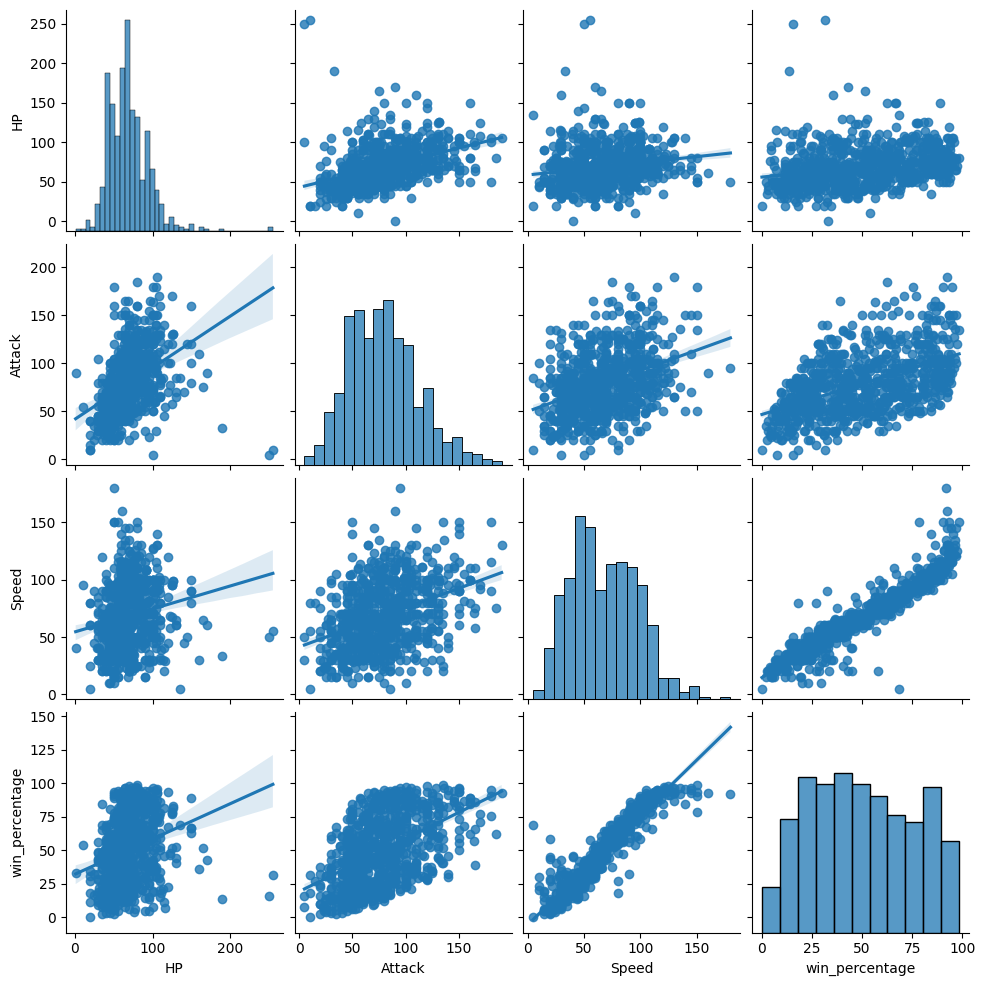

                         Name  win_percentage   HP  Attack  Speed
154           Mega Aerodactyl       98.449612   80     135    150
512                   Weavile       97.478992   70     120    125
703    Tornadus Therian Forme       96.800000   79     100    121
19              Mega Beedrill       96.638655   65     150    145
153                Aerodactyl       96.453901   80     105    130
476              Mega Lopunny       96.124031   65     136    135
726                  Greninja       96.062992   72      95    122
716  Meloetta Pirouette Forme       95.934959  100     128    128
164             Mega Mewtwo Y       95.200000  106     150    140
349             Mega Sharpedo       95.000000   70     140    105


In [51]:
sns.pairplot(correlation_data, kind='reg')
plt.show()

top_10_pokemon = pokemon[['Name', 'win_percentage', 'HP', 'Attack', 'Speed']].sort_values(by='win_percentage', ascending=False).head(10)

print(top_10_pokemon)


# **The top 10 Pokémon with the highest win percentage include:**

**Mega Aerodactyl (98.45%)
Weavile (97.48%)
Tornadus Therian Forme (96.80%)
Mega Beedrill (96.64%)
Aerodactyl (96.45%)
Mega Lopunny (96.12%)
Greninja (96.06%)
Meloetta Pirouette Forme (95.93%)
Mega Mewtwo Y (95.20%)
Mega Sharpedo (95.00%)
Speed is Dominant: The top Pokémon all have very high Speed (especially Mega Aerodactyl, with 150 Speed). This aligns with the strong correlation between Speed and win percentage.**


# **Machine Learning**

In [53]:
X = pokemon[['HP', 'Attack', 'Speed']]  # Features
y = pokemon['win_percentage']  # Target

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Linear Regression**

In [56]:
# Replace NaN values in 'win_percentage' with 0
pokemon['win_percentage'].fillna(0, inplace=True)

# Now proceed with your model training
X = pokemon[['HP', 'Attack', 'Speed']]  # Features
y = pokemon['win_percentage']  # Target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)
y_pred_lr = linear_regressor.predict(X_test)

# **Random forest**

In [57]:
# Initialize and train Random Forest
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_regressor.predict(X_test)

# **XGBoost**

In [58]:
# Initialize and train XGBoost
xgb_regressor = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_regressor.fit(X_train, y_train)

# Predict on the test set
y_pred_xgb = xgb_regressor.predict(X_test)

In [59]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print(f"MAE for Linear Regression: {mae_lr:.4f}")
print(f"MAE for Random Forest: {mae_rf:.4f}")
print(f"MAE for XGBoost: {mae_xgb:.4f}")


MAE for Linear Regression: 6.6023
MAE for Random Forest: 5.7746
MAE for XGBoost: 6.5217


# **Random Forest Regressor has the lowest MAE (5.7746), meaning it performs the best at predicting the win percentage of Pokémon among the three models. Linear Regression and XGBoost perform similarly but with higher MAE compared to Random Forest, indicating that they are not as accurate for this specific task. The Random Forest model is the most accurate for predicting the win percentage based on the features (HP, Attack, Speed).**